# 26 — Backpropagation Through Time

[Notebook 25](./25_vanilla_rnns_and_sequence_processing.ipynb) followed a recurrent network forward through time. This notebook reverses that computation: first through one RNN step, then through a complete sequence.

## Learning objectives

- derive and implement one-step RNN gradients;
- distinguish direct and future hidden-state gradients;
- implement backpropagation through time (BPTT);
- verify local and sequence gradients numerically;
- observe vanishing and exploding gradients;
- clip gradients by their global norm;
- explain gradient routing through padding masks.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import eval_numerical_gradient_array, relative_error
from cs231n_practice.rnn_layers import rnn_forward, rnn_forward_masked, rnn_step_forward

SEED = 42
generator = np.random.default_rng(SEED)


## 1. Backward through tanh

One recurrent step computes

$$
a_t=x_tW_x+h_{t-1}W_h+b,
$$

$$
h_t=\tanh(a_t).
$$

Suppose dh_next is the upstream gradient with shape $(N,H)$. Since the cache stores $h_t=\tanh(a_t)$,

$$
da_t=dh_t\odot(1-h_t^2).
$$

The symbol $\odot$ means elementwise multiplication. The upstream gradient, hidden state, local derivative, and pre-activation gradient all have shape $(N,H)$.

### Exercise 1 — Apply the local derivative


In [3]:
example_h_next = np.array([[0.0, 0.5], [-0.25, 0.8]])
example_dh_next = np.array([[2.0, -1.0], [0.5, 3.0]])

# multiply the upstream gradient by the local tanh derivative.
dpre_activation = example_dh_next * (1 - example_h_next**2)

expected = np.array([[2.0, -0.75], [0.46875, 1.08]])
np.testing.assert_allclose(dpre_activation, expected)
assert dpre_activation.shape == example_h_next.shape


## 2. Gradients for one recurrent step

After calculating $da_t$, the remaining derivatives are affine-layer derivatives:

- $dx_t=da_tW_x^T$, with shape $(N,D)$;
- $dh_{t-1}=da_tW_h^T$, with shape $(N,H)$;
- $dW_x=x_t^Tda_t$, with shape $(D,H)$;
- $dW_h=h_{t-1}^Tda_t$, with shape $(H,H)$;
- $db=\sum_n da_t^{(n)}$, with shape $(H,)$. 

The bias was broadcast across the $N$ examples in the forward pass, so its gradient sums over the batch axis.

### Exercise 2 — Implement one-step backward

The cache order is (x_t, h_previous, weights_x, weights_h, h_next). Return gradients in the corresponding order dx_t, dh_previous, dweights_x, dweights_h, and dbias.


In [7]:
def rnn_step_backward(dh_next, cache):
    """Backpropagate through one vanilla-RNN time step."""
    x_t, h_previous, weights_x, weights_h, h_next = cache
    # calculate da, dx_t, dh_previous, dweights_x, dweights_h, dbias.
    da = dh_next * (1 - h_next**2)
    dx_t = da @ weights_x.T
    dh_previous = da @ weights_h.T
    dweights_x = x_t.T @ da
    dweights_h = h_previous.T @ da
    dbias = np.sum(da, axis=0)

    return dx_t, dh_previous, dweights_x, dweights_h, dbias


step_x = generator.normal(size=(3, 4))
step_h_previous = generator.normal(size=(3, 5))
step_weights_x = generator.normal(scale=0.2, size=(4, 5))
step_weights_h = generator.normal(scale=0.2, size=(5, 5))
step_bias = generator.normal(scale=0.1, size=5)
step_dh = generator.normal(size=(3, 5))
_, step_cache = rnn_step_forward(
    step_x, step_h_previous, step_weights_x, step_weights_h, step_bias
)
step_gradients = rnn_step_backward(step_dh, step_cache)
expected_shapes = (
    step_x.shape, step_h_previous.shape, step_weights_x.shape,
    step_weights_h.shape, step_bias.shape,
)
for gradient, expected_shape in zip(step_gradients, expected_shapes):
    assert gradient.shape == expected_shape


## 3. Numerical check of one step

The numerical checker treats step_dh as the upstream gradient and compares each analytical derivative against small perturbations of its forward input.

### Exercise 3 — Check every one-step gradient

Run this after Exercise 2. Errors should normally be below $10^{-8}$ for these float64 values.


In [8]:
analytical_step = rnn_step_backward(step_dh, step_cache)
numerical_step = (
    eval_numerical_gradient_array(
        lambda value: rnn_step_forward(value, step_h_previous, step_weights_x, step_weights_h, step_bias)[0],
        step_x, step_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_step_forward(step_x, value, step_weights_x, step_weights_h, step_bias)[0],
        step_h_previous, step_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_step_forward(step_x, step_h_previous, value, step_weights_h, step_bias)[0],
        step_weights_x, step_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_step_forward(step_x, step_h_previous, step_weights_x, value, step_bias)[0],
        step_weights_h, step_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_step_forward(step_x, step_h_previous, step_weights_x, step_weights_h, value)[0],
        step_bias, step_dh,
    ),
)
for name, analytical, numerical in zip(
    ("dx_t", "dh_previous", "dW_x", "dW_h", "db"),
    analytical_step,
    numerical_step,
):
    error = relative_error(analytical, numerical)
    print(f"{name:12s}: {error:.3e}")
    assert error < 1e-8


dx_t        : 6.693e-11
dh_previous : 9.869e-11
dW_x        : 7.043e-11
dW_h        : 6.820e-11
db          : 1.985e-11


## 4. Backpropagation through the complete sequence

A hidden state can affect the loss through two paths: directly through an output computed at that time step, and indirectly through later recurrent states. Its total gradient is therefore

$$
dh_t^{\mathrm{total}}=dh_t^{\mathrm{direct}}+dh_t^{\mathrm{future}}.
$$

In code, dh[:, t, :] represents the direct contribution and dh_carry represents the contribution propagated back from later recurrent steps. At the final step, dh_carry starts at zero. After processing step $t$, the returned gradient with respect to $h_{t-1}$ becomes dh_carry for the next backward iteration. It is a previous-state gradient from the current step's viewpoint, but it arrives from the future when we move to step $t-1$.

If the model has only a final loss, all earlier direct gradients are zero: dh[:, :-1, :] = 0. The final gradient enters at $t=T-1$ and is then carried through every earlier recurrent step. The general addition still works because each earlier total is simply zero plus dh_carry.

We iterate from $T-1$ down to zero because step $t$ must return its gradient before step $t-1$ can use it. The same parameters were used at every step, so dweights_x, dweights_h, and dbias are summed across time. Each input is a distinct value, so every dx_t is instead stored at dx[:, t, :].

### Exercise 4 — Implement BPTT

At every reverse step, compute dh_total = dh[:, t, :] + dh_carry, call rnn_step_backward, and use its returned previous-state gradient as the new dh_carry.


In [13]:
def rnn_backward(dh, caches):
    """Backpropagate through a complete vanilla-RNN sequence."""
    num_examples, num_steps, hidden_dim = dh.shape

    # Read dimensions and shared parameters from one step cache.
    first_x, _, weights_x, weights_h, _ = caches[0]
    input_dim = first_x.shape[1]

    # One input gradient for every example and time step.
    dx = np.zeros(
        (num_examples, num_steps, input_dim),
        dtype=np.result_type(dh, first_x),
    )

    # This carries the recurrent gradient from t+1 into t.
    dh_carry = np.zeros(
        (num_examples, hidden_dim),
        dtype=dh.dtype,
    )

    # Shared parameters receive contributions from every time step.
    dweights_x_total = np.zeros_like(weights_x)
    dweights_h_total = np.zeros_like(weights_h)
    dbias_total = np.zeros(hidden_dim, dtype=dh.dtype)

    # Reverse order: T-1, T-2, ..., 0.
    for t in range(num_steps - 1, -1, -1):
        # h_t affects the loss directly and through future recurrent steps.
        dh_total = dh[:, t, :] + dh_carry

        (
            dx_t,
            dh_carry,
            dweights_x,
            dweights_h,
            dbias,
        ) = rnn_step_backward(
            dh_total,
            caches[t],
        )

        # Each input position has its own gradient.
        dx[:, t, :] = dx_t

        # The parameters are shared, so their gradients accumulate.
        dweights_x_total += dweights_x
        dweights_h_total += dweights_h
        dbias_total += dbias

    # After processing t=0, dh_carry is the gradient of h0.
    dh0 = dh_carry

    return (
        dx,
        dh0,
        dweights_x_total,
        dweights_h_total,
        dbias_total,
    )


sequence_x = generator.normal(size=(2, 3, 4))
sequence_h0 = generator.normal(size=(2, 5))
sequence_weights_x = generator.normal(scale=0.2, size=(4, 5))
sequence_weights_h = generator.normal(scale=0.2, size=(5, 5))
sequence_bias = generator.normal(scale=0.1, size=5)
sequence_hidden, sequence_caches = rnn_forward(
    sequence_x, sequence_h0, sequence_weights_x,
    sequence_weights_h, sequence_bias,
)
sequence_dh = generator.normal(size=sequence_hidden.shape)
sequence_gradients = rnn_backward(sequence_dh, sequence_caches)
expected_shapes = (
    sequence_x.shape, sequence_h0.shape, sequence_weights_x.shape,
    sequence_weights_h.shape, sequence_bias.shape,
)
for gradient, expected_shape in zip(sequence_gradients, expected_shapes):
    assert gradient.shape == expected_shape


## 5. Numerical check of the full sequence

This catches three common errors: forgetting the direct dh at a time step, overwriting shared-parameter gradients instead of adding them, and traversing time in the wrong direction.

### Exercise 5 — Check all BPTT gradients


In [14]:
analytical_sequence = rnn_backward(sequence_dh, sequence_caches)
numerical_sequence = (
    eval_numerical_gradient_array(
        lambda value: rnn_forward(value, sequence_h0, sequence_weights_x, sequence_weights_h, sequence_bias)[0],
        sequence_x, sequence_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_forward(sequence_x, value, sequence_weights_x, sequence_weights_h, sequence_bias)[0],
        sequence_h0, sequence_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_forward(sequence_x, sequence_h0, value, sequence_weights_h, sequence_bias)[0],
        sequence_weights_x, sequence_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_forward(sequence_x, sequence_h0, sequence_weights_x, value, sequence_bias)[0],
        sequence_weights_h, sequence_dh,
    ),
    eval_numerical_gradient_array(
        lambda value: rnn_forward(sequence_x, sequence_h0, sequence_weights_x, sequence_weights_h, value)[0],
        sequence_bias, sequence_dh,
    ),
)
for name, analytical, numerical in zip(
    ("dx", "dh0", "dW_x", "dW_h", "db"),
    analytical_sequence,
    numerical_sequence,
):
    error = relative_error(analytical, numerical)
    print(f"{name:5s}: {error:.3e}")
    assert error < 1e-8


dx   : 1.539e-10
dh0  : 1.094e-10
dW_x : 1.427e-09
dW_h : 5.964e-10
db   : 3.489e-11


## 6. Vanishing and exploding gradients

A gradient reaching an early state repeatedly passes through the recurrent transformation and the tanh derivative. Products of many Jacobians can shrink toward zero or grow rapidly. Saturated tanh values make $1-h_t^2$ small and encourage vanishing gradients.

The experiment sends loss only into the final hidden state and records the norm while it travels backward through an untrained toy RNN.

### Exercise 6 — Compare recurrent scales

Run the plot and explain why a larger recurrent scale can amplify gradients but can also push tanh into saturation.


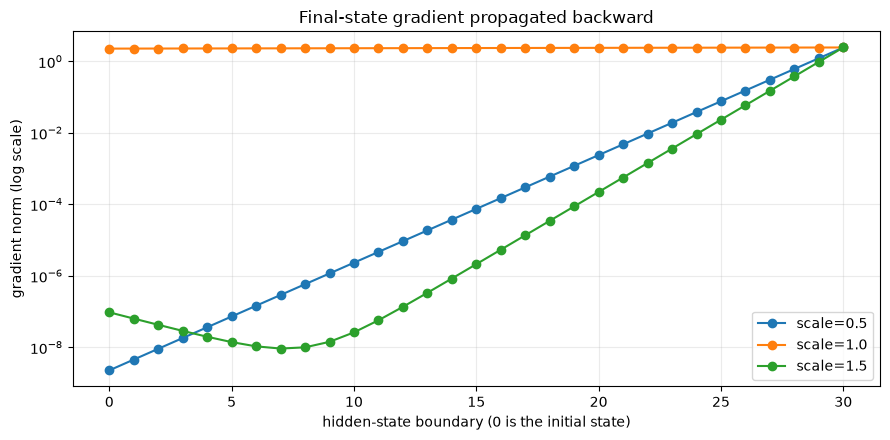

In [19]:
def gradient_norms_to_initial_state(caches):
    """Track a final-state gradient backward through the cached steps."""
    hidden_dim = caches[0][1].shape[1]
    gradient = np.ones((1, hidden_dim))
    norms = [np.linalg.norm(gradient)]
    for cache in reversed(caches):
        _, gradient, _, _, _ = rnn_step_backward(gradient, cache)
        norms.append(np.linalg.norm(gradient))
    return np.array(norms[::-1])


num_steps = 30
hidden_dim = 6
flow_x = np.zeros((1, num_steps, hidden_dim))
flow_x[:, 0, :] = 0.05
flow_h0 = np.zeros((1, hidden_dim))
flow_weights_x = np.eye(hidden_dim)
flow_bias = np.zeros(hidden_dim)

fig, ax = plt.subplots(figsize=(9, 4.5))
for recurrent_scale in (0.5, 1.0, 1.5):
    flow_weights_h = recurrent_scale * np.eye(hidden_dim)
    _, flow_caches = rnn_forward(
        flow_x, flow_h0, flow_weights_x, flow_weights_h, flow_bias
    )
    norms = gradient_norms_to_initial_state(flow_caches)
    ax.semilogy(
        range(num_steps + 1), norms, marker="o", label=f"scale={recurrent_scale}"
    )
ax.set_xlabel("hidden-state boundary (0 is the initial state)")
ax.set_ylabel("gradient norm (log scale)")
ax.set_title("Final-state gradient propagated backward")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# With scale 0.5, the gradient rapidly vanishes as it is propagated toward
# the initial state. With scale 1.0, its norm stays comparatively stable.
# Scale 1.5 does not produce a useful large gradient here: stronger recurrent
# activations saturate tanh, whose small derivative makes the early gradient
# vanish too. Large recurrent weights can cause explosion in other settings,
# but their interaction with the activation derivative determines the result.


## 7. Global-norm gradient clipping

Gradient clipping limits the update after gradients have been computed. For gradients $g_1,\ldots,g_k$, define

$$
\lVert g\rVert=\sqrt{\sum_i\sum_j(g_i)_j^2}.
$$

If the norm exceeds threshold $c$, multiply every gradient by the same factor $c/\lVert g\rVert$. A common factor preserves the direction of the combined gradient vector.

### Exercise 7 — Implement global-norm clipping


In [20]:
def clip_gradients_by_global_norm(gradients, max_norm):
    """Return clipped gradient copies and the original global norm."""
    # Treat all gradient arrays as parts of one long gradient vector: sum
    # every squared element first, then take one square root.
    squared_norm = sum(
        np.sum(gradient**2) for gradient in gradients.values()
    )
    global_norm = float(np.sqrt(squared_norm))

    # Leave a sufficiently small gradient unchanged. If it is too large,
    # use one common factor so the combined gradient keeps its direction.
    scale = 1.0
    if global_norm > max_norm:
        scale = max_norm / global_norm

    # Multiplication creates new arrays even when scale is 1.0, so the
    # caller's original gradients are not modified.
    clipped = {
        name: gradient * scale
        for name, gradient in gradients.items()
    }
    return clipped, global_norm


large_gradients = {
    "weights_x": np.array([[3.0, 4.0]]),
    "weights_h": np.array([[0.0, 12.0]]),
}
clipped, original_norm = clip_gradients_by_global_norm(
    large_gradients, max_norm=5.0
)
clipped_norm = np.sqrt(sum(np.sum(value**2) for value in clipped.values()))
np.testing.assert_allclose(original_norm, 13.0)
np.testing.assert_allclose(clipped_norm, 5.0)
assert all(clipped[name] is not value for name, value in large_gradients.items())


## 8. Optional: backward through a padding mask

For a valid row, the masked forward pass selected the recurrent candidate. For a padded row, it selected the previous state directly. Backward propagation must follow the same selected paths.

With a valid mask of shape $(N,1)$, send total_dh multiplied by valid into the recurrent candidate. Send total_dh multiplied by the inverse mask directly to the preceding hidden state. After the recurrent backward step, add these two previous-state contributions.

### Exercise 8 — Implement masked BPTT (optional)


In [21]:
def rnn_backward_masked(dh, caches):
    """Backpropagate through a masked vanilla-RNN sequence."""
    # Read dimensions and shared parameters from the first step cache.
    first_step_cache, _ = caches[0]
    first_x, _, weights_x, weights_h, _ = first_step_cache
    num_examples, num_steps, hidden_dim = dh.shape
    input_dim = first_x.shape[1]

    dx = np.zeros((num_examples, num_steps, input_dim), dtype=dh.dtype)
    dh_carry = np.zeros((num_examples, hidden_dim), dtype=dh.dtype)
    dweights_x = np.zeros_like(weights_x)
    dweights_h = np.zeros_like(weights_h)
    dbias = np.zeros(hidden_dim, dtype=dh.dtype)

    for t in range(num_steps - 1, -1, -1):
        step_cache, valid = caches[t]  # valid has shape (N, 1)
        total_dh = dh[:, t, :] + dh_carry

        # A valid row used the recurrent candidate in the forward pass, so
        # only that row enters rnn_step_backward. A padded row selected the
        # previous state directly and follows the identity path instead.
        dcandidate = total_dh * valid
        dh_identity = total_dh * (~valid)

        dx_t, dh_branch, dweights_x_t, dweights_h_t, dbias_t = (
            rnn_step_backward(dcandidate, step_cache)
        )
        dx[:, t, :] = dx_t

        # Both paths lead to the previous hidden state. Only one is active
        # per row, but expressing the result as a sum mirrors backpropagation
        # through the masked branch in the computational graph.
        dh_carry = dh_branch + dh_identity
        dweights_x += dweights_x_t
        dweights_h += dweights_h_t
        dbias += dbias_t

    dh0 = dh_carry
    return dx, dh0, dweights_x, dweights_h, dbias


masked_x = generator.normal(size=(2, 3, 2))
masked_h0 = generator.normal(size=(2, 3))
masked_lengths = np.array([1, 3])
masked_weights_x = generator.normal(scale=0.2, size=(2, 3))
masked_weights_h = generator.normal(scale=0.2, size=(3, 3))
masked_bias = generator.normal(scale=0.1, size=3)
masked_hidden, masked_caches = rnn_forward_masked(
    masked_x, masked_h0, masked_lengths, masked_weights_x,
    masked_weights_h, masked_bias,
)
masked_dh = generator.normal(size=masked_hidden.shape)

masked_gradients = rnn_backward_masked(masked_dh, masked_caches)
numerical_masked_dx = eval_numerical_gradient_array(
    lambda value: rnn_forward_masked(
        value, masked_h0, masked_lengths, masked_weights_x,
        masked_weights_h, masked_bias
    )[0],
    masked_x, masked_dh,
)
masked_dx_error = relative_error(masked_gradients[0], numerical_masked_dx)
print(f"masked dx error: {masked_dx_error:.3e}")
assert masked_dx_error < 1e-8


masked dx error: 2.511e-11


## 9. Reflection

1. Why can the tanh derivative use the cached hidden state?
2. What are the shapes of dx_t, dh_previous, dW_x, dW_h, and dbias?
3. Why is an intermediate hidden-state gradient a sum of two contributions?
4. Why does BPTT iterate from $T-1$ toward zero?
5. Why are shared-parameter gradients accumulated across time?
6. What causes gradients to vanish or explode across long sequences?
7. What does global-norm clipping change, and what does it preserve?
8. Where does the gradient go at a padded time step?

### Answers

1. Because $h_t=\tanh(a_t)$, the derivative of tanh can be calculated directly as $1-h_t^2$ using the cached hidden state.
2. dx_t: $(N,D)$, dh_previous: $(N,H)$, dW_x: $(D,H)$, dW_h: $(H,H)$, and dbias: $(H,)$.
3. An intermediate hidden state can affect the loss directly through the output at its own time step and indirectly through all later recurrent states. Its total gradient is the sum of the direct gradient and the gradient carried back from the future.
4. we go backwards during backpropagation - to calculate gradient of preceding step we first need gradient of its next step. BPTT iterates backward because the gradient at step $t-1$ depends on the previous-state gradient returned by step $t$. The later step must therefore be processed first.
5. same parameters impact result on all steps meaning their contributions should be summed. The same $W_x$, $W_h$, and bias are used at every time step. Each use affects the final loss, so their gradient contributions must be summed across all steps.
6. Gradients repeatedly multiply by the recurrent weight matrix and the local tanh derivatives. Products whose effective magnitudes are mostly below one shrink and cause vanishing gradients; products with sufficiently large magnitudes can grow and cause exploding gradients. Saturated tanh activations have derivatives close to zero and encourage vanishing.
7. Global-norm clipping reduces the magnitude of the combined gradient when it exceeds a threshold. Because every gradient array is multiplied by the same factor, it preserves the direction and relative proportions of the combined gradient vector.
8. simply go to previous step without any transformation. At a padded step, the gradient bypasses the recurrent candidate and travels directly to the previous hidden state through the identity path. That padded step contributes zero gradient to its input and recurrent parameters.
